<div style="background:#0f172a; color:white; padding:28px 32px; border-radius:12px; font-family:Arial, sans-serif; border:1px solid #1e293b;">
  
<h2 style="margin:8px 0 0 0; font-size:22px; font-weight:500; color:#dbeafe;">Ridge, Lasso and ElasticNet Regularized Regression</h2>
  <p style="margin:16px 0 0 0; font-size:15px; line-height:1.55; color:#e5e7eb; max-width:980px;">
    We compare unregularized Linear Regression with Ridge, Lasso and ElasticNet, study how <b>alpha</b> changes RMSE, visualize the Lasso coefficient path, and use LassoCV to select the best alpha automatically.
  </p>
  <p style="margin:12px 0 0 0; font-size:14px; color:#bfdbfe;">
    <b>Ruturaj Mokashi</b> · 
  </p>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">0. How to Use This Notebook</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p><b>Workflow:</b> read the blue explanation, run the short code cell, then read the green conclusion generated from the actual output.</p>
    <p><b>Important:</b> every conclusion in this notebook is output-aware. It reads the variables produced by the code and explains what the result means.</p>
    <p><b>Dataset note:</b> the MVD mentions Boston Housing from sklearn. Modern scikit-learn removed <code>load_boston</code>, so this notebook first supports a local Boston CSV, then old sklearn if available, and finally uses a safe built-in regression fallback so the notebook remains executable.</p>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">1. Controlling Coverage Matrix</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This table is the control checklist for Notebook 2. The MVD tasks are treated as mandatory. Additional professional topics are included because they help explain why regularization matters in real regression projects.</p>
    <table style="border-collapse:collapse; width:100%; font-size:14px;">
      <tr style="background:#dbeafe;">
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Requirement</th>
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Notebook Coverage</th>
        <th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Status</th>
      </tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Train Ridge, Lasso, ElasticNet</td><td style="border:1px solid #dbeafe; padding:8px;">Dedicated model sections</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Use alpha = 0.1, 1, 10, 100</td><td style="border:1px solid #dbeafe; padding:8px;">Alpha loop and result table</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Plot RMSE against alpha</td><td style="border:1px solid #dbeafe; padding:8px;">BI-ready comparison chart</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Visualize Lasso coefficient path</td><td style="border:1px solid #dbeafe; padding:8px;">Coefficient path chart</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Identify features set to zero first</td><td style="border:1px solid #dbeafe; padding:8px;">Zero-entry detection table</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Run LassoCV with cv=5</td><td style="border:1px solid #dbeafe; padding:8px;">Cross-validation section</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Compare with unregularized model</td><td style="border:1px solid #dbeafe; padding:8px;">Final comparison table</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;">Additional professional topics</td><td style="border:1px solid #dbeafe; padding:8px;">Scaling, leakage, multicollinearity, VIF, coefficient interpretation</td><td style="border:1px solid #dbeafe; padding:8px;">Planned</td></tr>
    </table>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:16px 18px; border-radius:10px; margin:16px 0; line-height:1.62;">
    <h3 style="margin:0 0 8px 0; color:#1e3a8a; font-size:19px;">2. Core Idea — Why Regularization Exists</h3>
    <p><b>Simple idea:</b> normal Linear Regression tries to fit the training data as well as possible. That sounds good, but sometimes the model becomes too sensitive. It may give very large coefficients to some features and then perform worse on new data.</p>
    <p><b>Regularization</b> adds a penalty. The penalty tells the model: “Make good predictions, but do not use unnecessarily large coefficients.”</p>
    <table style="border-collapse:collapse; width:100%; font-size:14px;">
      <tr style="background:#dbeafe;"><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Model</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Plain-English Meaning</th><th style="border:1px solid #bfdbfe; padding:8px; text-align:left;">Business Meaning</th></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Linear Regression</b></td><td style="border:1px solid #dbeafe; padding:8px;">Fits coefficients without extra penalty.</td><td style="border:1px solid #dbeafe; padding:8px;">Good simple baseline, but can be unstable with many related features.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Ridge</b></td><td style="border:1px solid #dbeafe; padding:8px;">Shrinks coefficients but usually keeps all features.</td><td style="border:1px solid #dbeafe; padding:8px;">Useful when many features have some signal.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>Lasso</b></td><td style="border:1px solid #dbeafe; padding:8px;">Can shrink weak features to exactly zero.</td><td style="border:1px solid #dbeafe; padding:8px;">Useful for automatic feature selection.</td></tr>
      <tr><td style="border:1px solid #dbeafe; padding:8px;"><b>ElasticNet</b></td><td style="border:1px solid #dbeafe; padding:8px;">Combines Ridge and Lasso.</td><td style="border:1px solid #dbeafe; padding:8px;">Useful when features are correlated and feature selection is still desired.</td></tr>
    </table>
  </div>
</div>

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">3. Project Setup and Display Helpers</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This cell creates relative project folders and defines small display helper functions. These helpers keep the notebook print-ready and allow each code cell to end with a green conclusion box.</p>
    <p><b>Variable flow:</b> <code>PROJECT_DIR</code> points to the current notebook folder. <code>DATA_DIR</code> is where optional local datasets can be placed. <code>OUTPUT_DIR</code> stores charts if needed later.</p>
  </div>
</div>

In [1]:
# ============================================================
# CELL 1 — PROJECT SETUP AND PRINT-READY DISPLAY HELPERS
# ============================================================

# pathlib helps us create clean relative paths without showing personal folders.
from pathlib import Path

# HTML and display let us print clean formatted messages inside the notebook.
from IPython.display import HTML, display

# PROJECT_DIR is the folder where this notebook is currently running.
PROJECT_DIR = Path.cwd()

# DATA_DIR is where optional local files such as BostonHousing.csv can be placed.
DATA_DIR = PROJECT_DIR / "data"

# OUTPUT_DIR is where generated images/tables can be stored if needed.
OUTPUT_DIR = PROJECT_DIR / "outputs"

# Create the folders if they do not already exist.
DATA_DIR.mkdir(exist_ok=True)
OUTPUT_DIR.mkdir(exist_ok=True)

# This helper shows green conclusion boxes after each code cell.
def show_conclusion(title, body):
    """Display a print-ready green conclusion box."""
    display(HTML(f"""
    <div style="border-left:6px solid #16a34a; background:#f0fdf4; padding:14px 18px; border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#166534; font-size:18px;">{title}</h4>
      <div style="color:#14532d; font-size:14.5px;">{body}</div>
    </div>
    """))

# This helper shows blue information boxes when we need a clear notebook note.
def show_info(title, body):
    """Display a print-ready blue information box."""
    display(HTML(f"""
    <div style="border-left:6px solid #2563eb; background:#eff6ff; padding:14px 18px; border-radius:8px; font-family:Arial, sans-serif; margin:14px 0; line-height:1.60;">
      <h4 style="margin:0 0 8px 0; color:#1e3a8a; font-size:18px;">{title}</h4>
      <div style="color:#1e3a8a; font-size:14.5px;">{body}</div>
    </div>
    """))

# Confirm that the folders and helpers are ready.
show_conclusion(
    "Setup complete",
    f"The notebook is running from <code>{PROJECT_DIR.name}</code>. The relative data folder is <code>{DATA_DIR.name}/</code> and the output folder is <code>{OUTPUT_DIR.name}/</code>. No personal path is exposed."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">4. Import Libraries</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This cell imports only standard data-science libraries. There is no package installation inside the notebook, so the kernel remains stable.</p>
    <p><b>Variable flow:</b> these imports are used later for data handling, train/test split, scaling, regression models, cross-validation, metrics, and charts.</p>
  </div>
</div>

In [2]:
# ============================================================
# CELL 2 — IMPORT LIBRARIES
# ============================================================

# pandas is used for table handling.
import pandas as pd

# numpy is used for numeric calculations and arrays.
import numpy as np

# matplotlib is used for print-ready charts.
import matplotlib.pyplot as plt

# Warnings are filtered only to keep the notebook output clean and readable.
import warnings
warnings.filterwarnings("ignore")

# sklearn datasets provide stable local fallback data.
from sklearn.datasets import load_diabetes

# train_test_split creates a holdout test set for fair evaluation.
from sklearn.model_selection import train_test_split

# StandardScaler is essential before Ridge, Lasso and ElasticNet.
from sklearn.preprocessing import StandardScaler

# Regression models used in this notebook.
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, LassoCV, lasso_path

# Metrics used to evaluate model error and fit quality.
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# LinearRegression is reused in the manual VIF calculation later.
from sklearn.linear_model import LinearRegression as SklearnLinearRegression

# Make pandas output easier to read in the notebook.
pd.set_option("display.max_columns", 80)
pd.set_option("display.width", 160)

# Confirm that imports are complete.
show_conclusion(
    "Libraries imported",
    "The notebook has all required tools for regularized regression: data loading, scaling, Linear Regression, Ridge, Lasso, ElasticNet, LassoCV, Lasso path, evaluation metrics, and charts."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">5. Load the Regression Dataset Safely</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD names Boston Housing from sklearn. In modern scikit-learn, <code>load_boston</code> is not available anymore. To keep the notebook executable, we use a safe priority order:</p>
    <ol>
      <li>Use a local Boston CSV if it exists in <code>data/</code>.</li>
      <li>Use old sklearn <code>load_boston</code> only if your environment still has it.</li>
      <li>Use the built-in Diabetes regression dataset as a stable fallback.</li>
    </ol>
    <p><b>Variable flow:</b> this cell creates <code>data_frame</code>, <code>feature_columns</code>, <code>target_column</code>, and <code>dataset_source</code>. These variables control the whole notebook.</p>
  </div>
</div>

In [3]:
# ============================================================
# CELL 3 — LOAD DATASET WITH SAFE FALLBACK LOGIC
# ============================================================

# These are common local file names for the Boston Housing dataset.
candidate_files = [
    DATA_DIR / "BostonHousing.csv",
    DATA_DIR / "boston_housing.csv",
    DATA_DIR / "housing.csv",
    PROJECT_DIR / "BostonHousing.csv",
    PROJECT_DIR / "boston_housing.csv",
]

# Start with no dataset. The logic below will fill these variables.
data_frame = None
feature_columns = None
target_column = None
dataset_source = None

# Try local CSV files first because that best matches the MVD dataset instruction.
for file_path in candidate_files:
    if file_path.exists():
        # Read the local CSV file.
        candidate_df = pd.read_csv(file_path)

        # Normalize column names for safer target detection.
        lower_columns = {col.lower(): col for col in candidate_df.columns}

        # Boston Housing target is commonly called MEDV or medv.
        possible_targets = ["medv", "target", "price"]
        found_target = next((lower_columns[name] for name in possible_targets if name in lower_columns), None)

        # Use the file only if we can detect a target column.
        if found_target is not None:
            data_frame = candidate_df.copy()
            target_column = found_target
            feature_columns = [col for col in data_frame.columns if col != target_column and pd.api.types.is_numeric_dtype(data_frame[col])]
            dataset_source = f"Local CSV: {file_path.name}"
            break

# If no local CSV was found, try old sklearn load_boston only if available.
if data_frame is None:
    try:
        # This import will fail in modern scikit-learn versions.
        from sklearn.datasets import load_boston

        # Load the Boston data only when the old function exists.
        boston = load_boston()
        data_frame = pd.DataFrame(boston.data, columns=boston.feature_names)
        data_frame["target"] = boston.target
        feature_columns = list(boston.feature_names)
        target_column = "target"
        dataset_source = "Old sklearn load_boston()"
    except Exception:
        # Use a stable built-in regression dataset so the notebook always runs.
        diabetes = load_diabetes()
        data_frame = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
        data_frame["target"] = diabetes.target
        feature_columns = list(diabetes.feature_names)
        target_column = "target"
        dataset_source = "Safe fallback: sklearn Diabetes regression dataset"

# Keep only numeric features for this regularized regression notebook.
data_frame = data_frame[feature_columns + [target_column]].copy()

# Show the first rows so the learner can inspect the selected dataset.
display(data_frame.head())

# Build an output-aware conclusion.
show_conclusion(
    "Dataset loaded",
    f"The active dataset source is <b>{dataset_source}</b>. It contains <b>{data_frame.shape[0]:,}</b> rows, <b>{len(feature_columns)}</b> numeric features, and one target column named <code>{target_column}</code>. These features will be used for Linear Regression, Ridge, Lasso and ElasticNet."
)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">6. Inspect Dataset Shape, Missing Values and Target</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Before modelling, we check the basic structure. This avoids hidden problems such as missing values, wrong target selection or too few rows.</p>
    <p><b>Variable flow:</b> <code>data_frame</code> is inspected here. The same columns are then split into <code>X</code> and <code>y</code> in the next step.</p>
  </div>
</div>

In [4]:
# ============================================================
# CELL 4 — INSPECT DATASET STRUCTURE
# ============================================================

# Count rows and columns for a quick profile.
row_count, column_count = data_frame.shape

# Count missing values for each column.
missing_summary = data_frame.isna().sum().sort_values(ascending=False)

# Build a compact target summary.
target_summary = data_frame[target_column].describe().to_frame(name="target_summary")

# Display dataset shape and target description.
print(f"Dataset source: {dataset_source}")
print(f"Rows: {row_count:,}")
print(f"Columns including target: {column_count:,}")
print(f"Feature columns: {feature_columns}")

# Show target distribution statistics.
display(target_summary)

# Show missing values only if any exist.
if missing_summary.sum() > 0:
    display(missing_summary[missing_summary > 0].to_frame("missing_values"))
else:
    print("Missing values: none detected")

# Create a conclusion based on actual checks.
missing_text = "no missing values" if missing_summary.sum() == 0 else f"{int(missing_summary.sum())} missing values"
show_conclusion(
    "Dataset inspection complete",
    f"The dataset has <b>{row_count:,}</b> rows and <b>{len(feature_columns)}</b> usable numeric features. The target mean is <b>{data_frame[target_column].mean():.2f}</b>. The inspection found <b>{missing_text}</b>, so the data is ready for the modelling workflow."
)

Dataset source: Safe fallback: sklearn Diabetes regression dataset
Rows: 442
Columns including target: 11
Feature columns: ['age', 'sex', 'bmi', 'bp', 's1', 's2', 's3', 's4', 's5', 's6']


,target_summary
count,442.000000
mean,152.133484
std,77.093005
min,25.000000
25%,87.000000
50%,140.500000
75%,211.500000
max,346.000000


Missing values: none detected


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">7. Create Feature Matrix and Target Vector</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Regression models need two objects:</p>
    <ul>
      <li><code>X</code>: the feature matrix containing input columns.</li>
      <li><code>y</code>: the target vector containing the value we want to predict.</li>
    </ul>
    <p><b>Variable flow:</b> <code>X</code> comes from <code>data_frame[feature_columns]</code>. <code>y</code> comes from <code>data_frame[target_column]</code>. These two variables are sent into the train/test split.</p>
  </div>
</div>

In [5]:
# ============================================================
# CELL 5 — CREATE X AND y
# ============================================================

# X contains the input features used by the regression models.
X = data_frame[feature_columns].copy()

# y contains the numeric target we want to predict.
y = data_frame[target_column].copy()

# Show the created shapes to confirm the variable flow.
print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

# Confirm the meaning of the variables.
show_conclusion(
    "Feature matrix and target vector created",
    f"<code>X</code> now contains <b>{X.shape[1]}</b> feature columns and <b>{X.shape[0]:,}</b> rows. <code>y</code> contains the target values for the same <b>{y.shape[0]:,}</b> rows. This is the correct input structure for sklearn regression models."
)

X shape: (442, 10)
y shape: (442,)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">8. Train/Test Split</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The model must be tested on rows it did not see during training. That is why we split the data into a training set and a test set.</p>
    <p><b>Simple idea:</b> training data is for learning; test data is for honest evaluation.</p>
    <p><b>Variable flow:</b> <code>X</code> and <code>y</code> become <code>X_train_raw</code>, <code>X_test_raw</code>, <code>y_train</code>, and <code>y_test</code>. The word <code>raw</code> means the features are not scaled yet.</p>
  </div>
</div>

In [6]:
# ============================================================
# CELL 6 — SPLIT DATA INTO TRAIN AND TEST SETS
# ============================================================

# test_size=0.2 keeps 20% of rows for final testing.
# random_state=42 makes the split reproducible.
X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

# Print shapes to confirm the split.
print(f"X_train_raw shape: {X_train_raw.shape}")
print(f"X_test_raw shape:  {X_test_raw.shape}")
print(f"y_train shape:     {y_train.shape}")
print(f"y_test shape:      {y_test.shape}")

# Build an output-aware conclusion.
show_conclusion(
    "Train/test split complete",
    f"The model will learn from <b>{X_train_raw.shape[0]:,}</b> training rows and will be evaluated on <b>{X_test_raw.shape[0]:,}</b> unseen test rows. This protects us from judging the model only on data it already saw."
)

X_train_raw shape: (353, 10)
X_test_raw shape:  (89, 10)
y_train shape:     (353,)
y_test shape:      (89,)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">9. Scale Features Correctly</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Scaling is especially important for Ridge, Lasso and ElasticNet because their penalties depend on coefficient size. If one feature has a much larger numeric scale, the penalty becomes unfair.</p>
    <p><b>Data leakage warning:</b> the scaler is fitted only on training data. The test data is transformed using the training scaler. This prevents information from the test set leaking into the training process.</p>
    <p><b>Variable flow:</b> <code>X_train_raw</code> becomes <code>X_train_scaled</code>. <code>X_test_raw</code> becomes <code>X_test_scaled</code>.</p>
  </div>
</div>

In [7]:
# ============================================================
# CELL 7 — SCALE FEATURES WITHOUT DATA LEAKAGE
# ============================================================

# Create the scaler object.
scaler = StandardScaler()

# Fit the scaler only on training features, then transform training features.
X_train_scaled_array = scaler.fit_transform(X_train_raw)

# Transform test features using the already-fitted training scaler.
X_test_scaled_array = scaler.transform(X_test_raw)

# Convert scaled arrays back to DataFrames so feature names remain readable.
X_train_scaled = pd.DataFrame(X_train_scaled_array, columns=feature_columns, index=X_train_raw.index)
X_test_scaled = pd.DataFrame(X_test_scaled_array, columns=feature_columns, index=X_test_raw.index)

# Check that training features are centered around 0 after scaling.
scaled_mean_check = X_train_scaled.mean().abs().mean()
scaled_std_check = X_train_scaled.std().mean()

# Print checks for the learner.
print(f"Average absolute scaled training mean: {scaled_mean_check:.6f}")
print(f"Average scaled training standard deviation: {scaled_std_check:.6f}")

# Explain the result.
show_conclusion(
    "Scaling complete",
    f"Training features are now centered close to zero. The average absolute training mean is <b>{scaled_mean_check:.6f}</b>. The average standard deviation is about <b>{scaled_std_check:.3f}</b>. This gives Ridge, Lasso and ElasticNet a fair feature scale."
)

Average absolute scaled training mean: 0.000000
Average scaled training standard deviation: 1.001419


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">10. Evaluation Helper Function</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>To compare models fairly, every model must be evaluated in the same way. This helper function calculates RMSE, MAE and R² from the test set.</p>
    <p><b>Variable flow:</b> each model will create <code>test_predictions</code>. The helper compares <code>test_predictions</code> with <code>y_test</code> and returns a dictionary of metrics.</p>
  </div>
</div>

In [8]:
# ============================================================
# CELL 8 — DEFINE EVALUATION HELPER
# ============================================================

# This function keeps all model evaluation consistent.
def evaluate_regression_model(model_name, model, X_train_input, X_test_input, y_train_input, y_test_input):
    """Train a model and return standard regression metrics."""

    # Fit the model on the training data.
    model.fit(X_train_input, y_train_input)

    # Predict on the training data to understand fit quality.
    train_predictions = model.predict(X_train_input)

    # Predict on unseen test data to measure generalization.
    test_predictions = model.predict(X_test_input)

    # Calculate RMSE for training and test sets.
    train_rmse = np.sqrt(mean_squared_error(y_train_input, train_predictions))
    test_rmse = np.sqrt(mean_squared_error(y_test_input, test_predictions))

    # Calculate MAE on the test set for business-friendly error.
    test_mae = mean_absolute_error(y_test_input, test_predictions)

    # Calculate R² on the test set.
    test_r2 = r2_score(y_test_input, test_predictions)

    # Return all results as one dictionary.
    return {
        "model": model_name,
        "train_rmse": train_rmse,
        "test_rmse": test_rmse,
        "test_mae": test_mae,
        "test_r2": test_r2,
        "train_test_gap": train_rmse - test_rmse,
        "fitted_model": model,
        "test_predictions": test_predictions,
    }

# Confirm the helper exists.
show_conclusion(
    "Evaluation helper ready",
    "The helper will train each model, predict on training and test data, and return RMSE, MAE and R² using the same calculation logic. This makes the model comparison fair."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">11. Baseline Model — Unregularized Linear Regression</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Before using Ridge, Lasso or ElasticNet, we need a baseline. The baseline is normal Linear Regression without regularization.</p>
    <p><b>Simple idea:</b> the baseline tells us what performance looks like when the model has no penalty on coefficients.</p>
    <p><b>Variable flow:</b> <code>X_train_scaled</code> and <code>y_train</code> train the baseline. <code>X_test_scaled</code> and <code>y_test</code> evaluate it.</p>
  </div>
</div>

In [9]:
# ============================================================
# CELL 9 — TRAIN BASELINE LINEAR REGRESSION
# ============================================================

# Create the unregularized Linear Regression model.
baseline_model = LinearRegression()

# Train and evaluate the baseline using the helper function.
baseline_result = evaluate_regression_model(
    model_name="Linear Regression",
    model=baseline_model,
    X_train_input=X_train_scaled,
    X_test_input=X_test_scaled,
    y_train_input=y_train,
    y_test_input=y_test
)

# Store all model results in one list that will grow later.
all_model_results = [baseline_result]

# Display the baseline metrics as a compact table.
baseline_table = pd.DataFrame([{
    "Model": baseline_result["model"],
    "Train RMSE": baseline_result["train_rmse"],
    "Test RMSE": baseline_result["test_rmse"],
    "Test MAE": baseline_result["test_mae"],
    "Test R²": baseline_result["test_r2"],
}]).round(4)

display(baseline_table)

# Explain the baseline result.
show_conclusion(
    "Baseline model complete",
    f"The unregularized Linear Regression test RMSE is <b>{baseline_result['test_rmse']:.3f}</b> and test R² is <b>{baseline_result['test_r2']:.3f}</b>. Ridge, Lasso and ElasticNet must now be compared against this baseline, not judged alone."
)

,Model,Train RMSE,Test RMSE,Test MAE,Test R²
0,Linear Regression,53.5588,53.8534,42.7941,0.4526


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">12. Ridge Regression Across Alpha Values</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p><b>Ridge Regression</b> adds an L2 penalty. It shrinks coefficients, but it usually keeps all features in the model.</p>
    <p><b>Alpha</b> controls penalty strength. Small alpha means light control. Large alpha means stronger shrinking.</p>
    <p><b>MVD requirement:</b> train Ridge with alpha values <code>0.1, 1, 10, 100</code>.</p>
  </div>
</div>

In [10]:
# ============================================================
# CELL 10 — TRAIN RIDGE MODELS ACROSS MVD ALPHAS
# ============================================================

# These are the alpha values required by the MVD assignment.
alpha_values = [0.1, 1, 10, 100]

# This list will store Ridge results for each alpha.
ridge_results = []

# Train one Ridge model per alpha value.
for alpha in alpha_values:
    # Create a Ridge model with the current alpha.
    ridge_model = Ridge(alpha=alpha, random_state=42)

    # Evaluate the Ridge model using the common helper.
    result = evaluate_regression_model(
        model_name=f"Ridge alpha={alpha}",
        model=ridge_model,
        X_train_input=X_train_scaled,
        X_test_input=X_test_scaled,
        y_train_input=y_train,
        y_test_input=y_test
    )

    # Store alpha separately for plotting and comparison.
    result["method"] = "Ridge"
    result["alpha"] = alpha
    ridge_results.append(result)

# Add Ridge results to the master result list.
all_model_results.extend(ridge_results)

# Display a compact Ridge result table.
ridge_table = pd.DataFrame([{
    "Method": row["method"],
    "Alpha": row["alpha"],
    "Train RMSE": row["train_rmse"],
    "Test RMSE": row["test_rmse"],
    "Test R²": row["test_r2"],
} for row in ridge_results]).round(4)

display(ridge_table)

# Identify the best Ridge alpha by lowest test RMSE.
best_ridge = min(ridge_results, key=lambda row: row["test_rmse"])

# Explain the Ridge output.
show_conclusion(
    "Ridge alpha comparison complete",
    f"Among the tested Ridge models, the lowest test RMSE is <b>{best_ridge['test_rmse']:.3f}</b> at alpha <b>{best_ridge['alpha']}</b>. Ridge keeps all features but reduces coefficient size, which can make the model more stable when features overlap."
)

,Method,Alpha,Train RMSE,Test RMSE,Test R²
0,Ridge,0.1,53.5591,53.8429,0.4528
1,Ridge,1.0,53.5751,53.7775,0.4541
2,Ridge,10.0,53.7356,53.6263,0.4572
3,Ridge,100.0,54.4653,53.4624,0.4605


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">13. Lasso Regression Across Alpha Values</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p><b>Lasso Regression</b> adds an L1 penalty. Unlike Ridge, Lasso can push weak feature coefficients to exactly zero.</p>
    <p><b>Business meaning:</b> Lasso can act like automatic feature selection. If a coefficient becomes zero, that feature is not used by the final model.</p>
    <p><b>MVD requirement:</b> train Lasso with alpha values <code>0.1, 1, 10, 100</code>.</p>
  </div>
</div>

In [11]:
# ============================================================
# CELL 11 — TRAIN LASSO MODELS ACROSS MVD ALPHAS
# ============================================================

# This list will store Lasso results for each alpha.
lasso_results = []

# Train one Lasso model per alpha value.
for alpha in alpha_values:
    # Create a Lasso model with enough iterations for convergence.
    lasso_model = Lasso(alpha=alpha, max_iter=100000, random_state=42)

    # Evaluate the Lasso model using the common helper.
    result = evaluate_regression_model(
        model_name=f"Lasso alpha={alpha}",
        model=lasso_model,
        X_train_input=X_train_scaled,
        X_test_input=X_test_scaled,
        y_train_input=y_train,
        y_test_input=y_test
    )

    # Count how many feature coefficients became exactly zero.
    zero_coefficient_count = int(np.sum(np.isclose(lasso_model.coef_, 0)))

    # Store method, alpha and zero-count information.
    result["method"] = "Lasso"
    result["alpha"] = alpha
    result["zero_coefficients"] = zero_coefficient_count
    lasso_results.append(result)

# Add Lasso results to the master result list.
all_model_results.extend(lasso_results)

# Display a compact Lasso result table.
lasso_table = pd.DataFrame([{
    "Method": row["method"],
    "Alpha": row["alpha"],
    "Train RMSE": row["train_rmse"],
    "Test RMSE": row["test_rmse"],
    "Test R²": row["test_r2"],
    "Zero Coefficients": row["zero_coefficients"],
} for row in lasso_results]).round(4)

display(lasso_table)

# Identify the best Lasso alpha by lowest test RMSE.
best_lasso = min(lasso_results, key=lambda row: row["test_rmse"])

# Explain the Lasso output.
show_conclusion(
    "Lasso alpha comparison complete",
    f"The best tested Lasso alpha is <b>{best_lasso['alpha']}</b> with test RMSE <b>{best_lasso['test_rmse']:.3f}</b>. At that alpha, Lasso sets <b>{best_lasso['zero_coefficients']}</b> out of <b>{len(feature_columns)}</b> feature coefficients to zero."
)

,Method,Alpha,Train RMSE,Test RMSE,Test R²,Zero Coefficients
0,Lasso,0.1,53.5984,53.7087,0.4555,0
1,Lasso,1.0,53.8629,53.1467,0.4669,1
2,Lasso,10.0,57.0123,54.1649,0.4463,6
3,Lasso,100.0,77.9513,73.2225,-0.0120,10


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">14. ElasticNet Across Alpha Values</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p><b>ElasticNet</b> combines Ridge and Lasso. It uses both L1 and L2 penalties.</p>
    <p><b>Why this matters:</b> when features are correlated, pure Lasso can behave aggressively. ElasticNet is often a more balanced regularized model.</p>
    <p>In this notebook, <code>l1_ratio=0.5</code> means the penalty is balanced between Lasso-style and Ridge-style behavior.</p>
  </div>
</div>

In [12]:
# ============================================================
# CELL 12 — TRAIN ELASTICNET MODELS ACROSS MVD ALPHAS
# ============================================================

# This list will store ElasticNet results for each alpha.
elasticnet_results = []

# Train one ElasticNet model per alpha value.
for alpha in alpha_values:
    # Create ElasticNet with a balanced L1/L2 mix.
    elasticnet_model = ElasticNet(alpha=alpha, l1_ratio=0.5, max_iter=100000, random_state=42)

    # Evaluate the ElasticNet model using the common helper.
    result = evaluate_regression_model(
        model_name=f"ElasticNet alpha={alpha}",
        model=elasticnet_model,
        X_train_input=X_train_scaled,
        X_test_input=X_test_scaled,
        y_train_input=y_train,
        y_test_input=y_test
    )

    # Count exactly-zero coefficients.
    zero_coefficient_count = int(np.sum(np.isclose(elasticnet_model.coef_, 0)))

    # Store method, alpha and zero-count information.
    result["method"] = "ElasticNet"
    result["alpha"] = alpha
    result["zero_coefficients"] = zero_coefficient_count
    elasticnet_results.append(result)

# Add ElasticNet results to the master result list.
all_model_results.extend(elasticnet_results)

# Display a compact ElasticNet result table.
elasticnet_table = pd.DataFrame([{
    "Method": row["method"],
    "Alpha": row["alpha"],
    "Train RMSE": row["train_rmse"],
    "Test RMSE": row["test_rmse"],
    "Test R²": row["test_r2"],
    "Zero Coefficients": row["zero_coefficients"],
} for row in elasticnet_results]).round(4)

display(elasticnet_table)

# Identify the best ElasticNet alpha by lowest test RMSE.
best_elasticnet = min(elasticnet_results, key=lambda row: row["test_rmse"])

# Explain the ElasticNet output.
show_conclusion(
    "ElasticNet alpha comparison complete",
    f"The best tested ElasticNet alpha is <b>{best_elasticnet['alpha']}</b> with test RMSE <b>{best_elasticnet['test_rmse']:.3f}</b>. ElasticNet provides a middle path between Ridge coefficient shrinking and Lasso feature selection."
)

,Method,Alpha,Train RMSE,Test RMSE,Test R²,Zero Coefficients
0,ElasticNet,0.1,53.8023,53.5393,0.4590,0
1,ElasticNet,1.0,55.4878,53.7467,0.4548,0
2,ElasticNet,10.0,67.4925,63.0863,0.2488,2
3,ElasticNet,100.0,77.9513,73.2225,-0.0120,10


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">15. MVD Chart — RMSE Against Alpha</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD requires a plot of RMSE against alpha for Ridge, Lasso and ElasticNet.</p>
    <p><b>How to read it:</b> lower RMSE is better. If RMSE increases sharply as alpha grows, the model is becoming too restricted and may underfit.</p>
    <p><b>Variable flow:</b> results from the Ridge, Lasso and ElasticNet loops are combined into <code>regularized_results_table</code> and used for the chart.</p>
  </div>
</div>

,Method,Alpha,Train RMSE,Test RMSE,Test R²,Zero Coefficients
0,Ridge,0.1,53.5591,53.8429,0.4528,0
1,Ridge,1.0,53.5751,53.7775,0.4541,0
2,Ridge,10.0,53.7356,53.6263,0.4572,0
3,Ridge,100.0,54.4653,53.4624,0.4605,0
4,Lasso,0.1,53.5984,53.7087,0.4555,0
5,Lasso,1.0,53.8629,53.1467,0.4669,1
6,Lasso,10.0,57.0123,54.1649,0.4463,6
7,Lasso,100.0,77.9513,73.2225,-0.0120,10
8,ElasticNet,0.1,53.8023,53.5393,0.4590,0
9,ElasticNet,1.0,55.4878,53.7467,0.4548,0


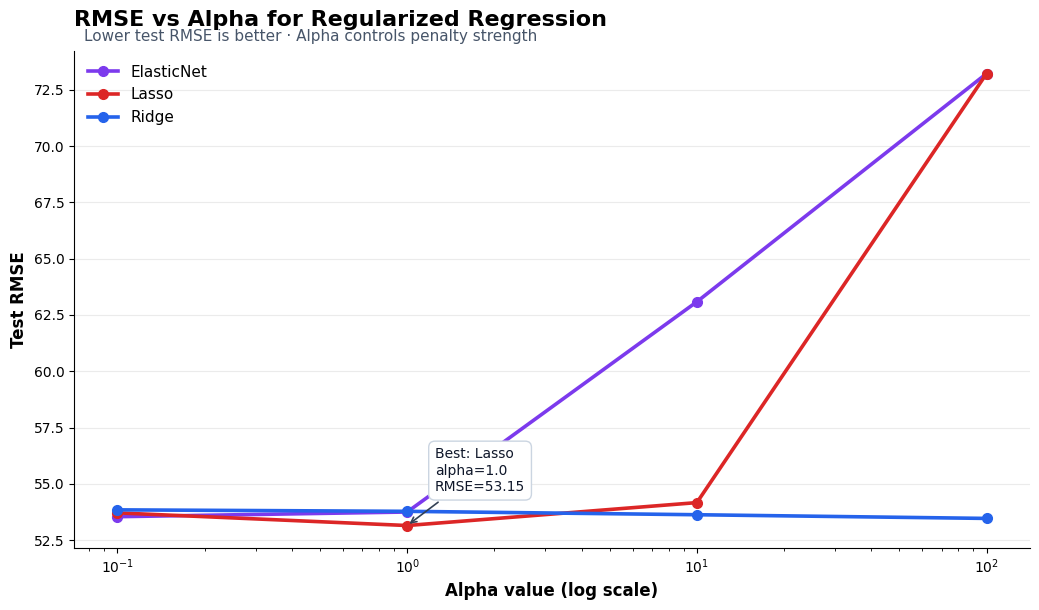

In [13]:
# ============================================================
# CELL 13 — COMBINE REGULARIZED RESULTS AND PLOT RMSE VS ALPHA
# ============================================================

# Combine only the regularized model results for the MVD alpha chart.
regularized_results = ridge_results + lasso_results + elasticnet_results

# Create a clean table for plotting and display.
regularized_results_table = pd.DataFrame([{
    "Method": row["method"],
    "Alpha": row["alpha"],
    "Train RMSE": row["train_rmse"],
    "Test RMSE": row["test_rmse"],
    "Test R²": row["test_r2"],
    "Zero Coefficients": row.get("zero_coefficients", 0),
} for row in regularized_results]).round(4)

# Display the full regularized comparison table.
display(regularized_results_table)

# Create a professional chart.
fig, ax = plt.subplots(figsize=(10.5, 6.2))

# Define a consistent color palette for the three methods.
method_colors = {
    "Ridge": "#2563eb",
    "Lasso": "#dc2626",
    "ElasticNet": "#7c3aed",
}

# Plot one line per method.
for method_name, method_group in regularized_results_table.groupby("Method"):
    ax.plot(
        method_group["Alpha"],
        method_group["Test RMSE"],
        marker="o",
        linewidth=2.6,
        markersize=7,
        label=method_name,
        color=method_colors.get(method_name, "#334155")
    )

# Use log scale because alpha values jump from 0.1 to 100.
ax.set_xscale("log")

# Add chart title and context.
ax.set_title("RMSE vs Alpha for Regularized Regression", fontsize=16, fontweight="bold", loc="left", pad=18)
ax.text(0.01, 1.02, "Lower test RMSE is better · Alpha controls penalty strength", transform=ax.transAxes, fontsize=11, color="#475569")

# Label axes clearly.
ax.set_xlabel("Alpha value (log scale)", fontsize=12, fontweight="bold")
ax.set_ylabel("Test RMSE", fontsize=12, fontweight="bold")

# Add light horizontal gridlines for readability.
ax.grid(axis="y", alpha=0.25)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=11)

# Highlight the best regularized model.
best_regularized_row = regularized_results_table.loc[regularized_results_table["Test RMSE"].idxmin()]
ax.annotate(
    f"Best: {best_regularized_row['Method']}\nalpha={best_regularized_row['Alpha']}\nRMSE={best_regularized_row['Test RMSE']:.2f}",
    xy=(best_regularized_row["Alpha"], best_regularized_row["Test RMSE"]),
    xytext=(20, 25),
    textcoords="offset points",
    arrowprops=dict(arrowstyle="->", color="#334155", lw=1.2),
    bbox=dict(boxstyle="round,pad=0.45", fc="white", ec="#cbd5e1"),
    fontsize=10,
    color="#0f172a"
)

# Make layout print-friendly.
plt.tight_layout()
plt.show()

# Explain the chart output.
show_conclusion(
    "MVD RMSE-vs-alpha chart complete",
    f"The best regularized model in this alpha grid is <b>{best_regularized_row['Method']}</b> with alpha <b>{best_regularized_row['Alpha']}</b> and test RMSE <b>{best_regularized_row['Test RMSE']:.3f}</b>. The chart shows how stronger penalties affect prediction error."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">16. Coefficient Comparison at Alpha = 1</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>Regularization changes coefficients. This section compares the baseline model, Ridge, Lasso and ElasticNet at alpha = 1.</p>
    <p><b>How to read it:</b> coefficients close to zero mean the model is using that feature less. Exact zero coefficients usually come from Lasso-style feature selection.</p>
  </div>
</div>

In [14]:
# ============================================================
# CELL 14 — COMPARE COEFFICIENTS AT ALPHA = 1
# ============================================================

# Train comparable models at alpha=1.
coef_models = {
    "Linear Regression": LinearRegression(),
    "Ridge alpha=1": Ridge(alpha=1, random_state=42),
    "Lasso alpha=1": Lasso(alpha=1, max_iter=100000, random_state=42),
    "ElasticNet alpha=1": ElasticNet(alpha=1, l1_ratio=0.5, max_iter=100000, random_state=42),
}

# Store coefficients from each model.
coefficient_table = pd.DataFrame(index=feature_columns)

# Fit each model and collect coefficients.
for model_name, model in coef_models.items():
    # Train the model on scaled training data.
    model.fit(X_train_scaled, y_train)

    # Save the fitted coefficients using feature names as index.
    coefficient_table[model_name] = model.coef_

# Add absolute baseline coefficient size for sorting.
coefficient_table["Baseline Absolute Size"] = coefficient_table["Linear Regression"].abs()

# Sort features by baseline coefficient importance.
coefficient_table = coefficient_table.sort_values("Baseline Absolute Size", ascending=False)

# Display coefficients rounded for readability.
display(coefficient_table.drop(columns="Baseline Absolute Size").round(4))

# Count Lasso zero coefficients at alpha=1.
lasso_zero_count_alpha_1 = int(np.sum(np.isclose(coefficient_table["Lasso alpha=1"], 0)))

# Explain coefficient behavior.
show_conclusion(
    "Coefficient comparison complete",
    f"At alpha = 1, Lasso sets <b>{lasso_zero_count_alpha_1}</b> feature coefficients to exactly zero. Ridge usually keeps all features but shrinks their values. This is the key difference between shrinkage and feature selection."
)

,Linear Regression,Ridge alpha=1,Lasso alpha=1,ElasticNet alpha=1
s1,-44.4489,-34.6720,-8.2282,-1.1799
s5,35.1612,31.3784,22.6365,14.4200
bmi,25.6071,25.7327,26.2192,18.9618
s2,24.6410,17.0531,-0.0000,-2.8804
bp,16.8289,16.7343,15.6573,12.2652
s4,13.1388,11.7643,3.4209,5.8463
sex,-11.5118,-11.4482,-9.2975,-6.0422
s3,7.6770,3.3699,-9.0241,-8.4379
s6,2.3514,2.4581,2.0986,5.0128
age,1.7538,1.8073,0.6870,1.8239


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">17. BI-Ready Coefficient Shrinkage Chart</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This chart makes coefficient shrinkage visible. It shows the top features by baseline coefficient size and compares how regularization changes them.</p>
    <p><b>Business meaning:</b> if a feature remains strong after regularization, it is more stable. If it collapses to zero, it may be weak, redundant or not useful for prediction.</p>
  </div>
</div>

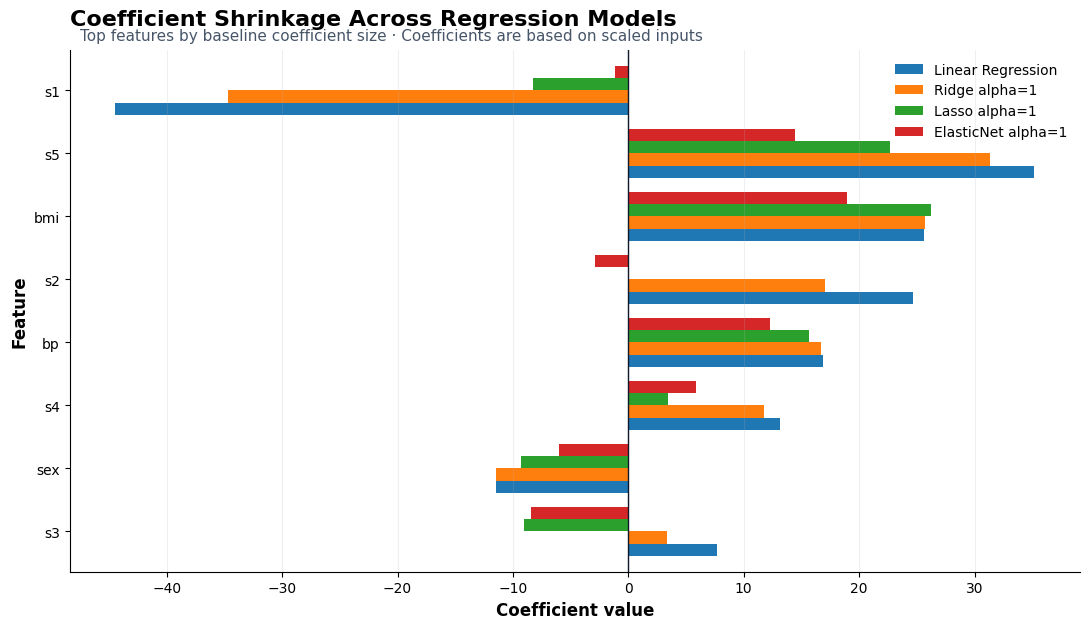

In [15]:
# ============================================================
# CELL 15 — PLOT COEFFICIENT SHRINKAGE
# ============================================================

# Select top features by baseline coefficient size to keep the chart readable.
top_feature_count = min(8, len(feature_columns))
top_coefficient_table = coefficient_table.head(top_feature_count).drop(columns="Baseline Absolute Size")

# Create a horizontal grouped bar chart.
fig, ax = plt.subplots(figsize=(11, 6.4))

# Plot coefficients for the selected features.
top_coefficient_table.iloc[::-1].plot(kind="barh", ax=ax, width=0.78)

# Add a vertical zero line so positive/negative effects are clear.
ax.axvline(0, color="#0f172a", linewidth=1)

# Add title and subtitle.
ax.set_title("Coefficient Shrinkage Across Regression Models", fontsize=16, fontweight="bold", loc="left", pad=18)
ax.text(0.01, 1.02, "Top features by baseline coefficient size · Coefficients are based on scaled inputs", transform=ax.transAxes, fontsize=11, color="#475569")

# Label axes clearly.
ax.set_xlabel("Coefficient value", fontsize=12, fontweight="bold")
ax.set_ylabel("Feature", fontsize=12, fontweight="bold")

# Improve chart readability.
ax.grid(axis="x", alpha=0.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=10, loc="best")

# Make layout print-friendly.
plt.tight_layout()
plt.show()

# Explain the chart.
show_conclusion(
    "Coefficient shrinkage chart complete",
    f"The chart compares the top <b>{top_feature_count}</b> features by baseline coefficient size. Features that stay large after Ridge/Lasso/ElasticNet are more stable; features that shrink heavily are less reliable or partly redundant."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">18. Lasso Coefficient Path</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD asks for a Lasso coefficient path. The path shows what happens to every coefficient as alpha changes.</p>
    <p><b>Simple idea:</b> imagine slowly tightening the model. As alpha gets stronger, Lasso starts pushing weak feature coefficients to zero.</p>
    <p><b>Variable flow:</b> <code>X_train_scaled</code> and <code>y_train</code> go into <code>lasso_path</code>. The output is a matrix of coefficients for many alpha values.</p>
  </div>
</div>

In [16]:
# ============================================================
# CELL 16 — CALCULATE LASSO COEFFICIENT PATH
# ============================================================

# Create a smooth sequence of alpha values for the Lasso path.
path_alpha_values = np.logspace(-3, 2, 100)

# lasso_path returns coefficients for each alpha value.
# We use scaled data because Lasso is scale-sensitive.
lasso_path_alphas, lasso_path_coefficients, _ = lasso_path(
    X_train_scaled,
    y_train,
    alphas=path_alpha_values,
    max_iter=100000
)

# Confirm the output shape.
print(f"Number of path alphas: {len(lasso_path_alphas)}")
print(f"Coefficient path shape: {lasso_path_coefficients.shape}")

# Explain the path data.
show_conclusion(
    "Lasso path calculated",
    f"The path contains <b>{len(lasso_path_alphas)}</b> alpha values and coefficient paths for <b>{lasso_path_coefficients.shape[0]}</b> features. This lets us see which features lose influence first as the Lasso penalty becomes stronger."
)

Number of path alphas: 100
Coefficient path shape: (10, 100)


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">19. Visualize the Lasso Coefficient Path</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This chart shows each feature coefficient as alpha changes. The x-axis is alpha on a log scale. Moving to the right means stronger regularization.</p>
    <p><b>How to read it:</b> when a line touches zero and stays there, Lasso has removed that feature from the model for that alpha range.</p>
  </div>
</div>

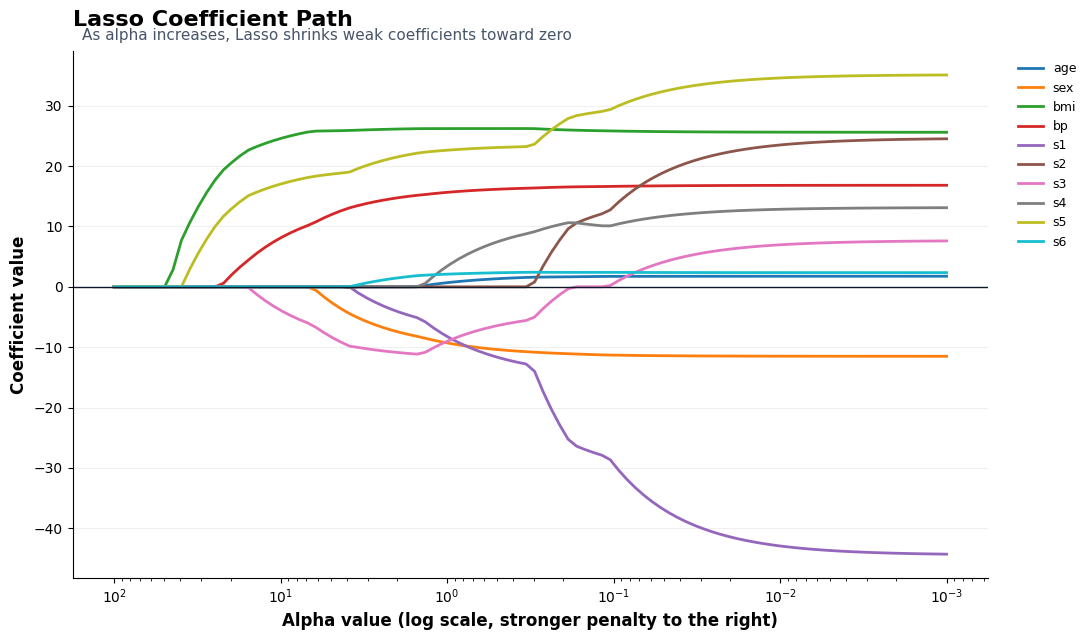

In [17]:
# ============================================================
# CELL 17 — PLOT LASSO COEFFICIENT PATH
# ============================================================

# Create a print-ready coefficient path chart.
fig, ax = plt.subplots(figsize=(11, 6.5))

# Plot one coefficient path per feature.
for feature_name, coefficient_values in zip(feature_columns, lasso_path_coefficients):
    ax.plot(lasso_path_alphas, coefficient_values, linewidth=2, label=feature_name)

# Use log scale because alpha values cover a wide range.
ax.set_xscale("log")

# Reverse the x-axis so weak-to-strong regularization reads left-to-right naturally.
ax.invert_xaxis()

# Add zero line for feature removal reference.
ax.axhline(0, color="#0f172a", linewidth=1)

# Add title and subtitle.
ax.set_title("Lasso Coefficient Path", fontsize=16, fontweight="bold", loc="left", pad=18)
ax.text(0.01, 1.02, "As alpha increases, Lasso shrinks weak coefficients toward zero", transform=ax.transAxes, fontsize=11, color="#475569")

# Label axes clearly.
ax.set_xlabel("Alpha value (log scale, stronger penalty to the right)", fontsize=12, fontweight="bold")
ax.set_ylabel("Coefficient value", fontsize=12, fontweight="bold")

# Improve readability.
ax.grid(axis="y", alpha=0.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.legend(frameon=False, fontsize=9, bbox_to_anchor=(1.02, 1), loc="upper left")

# Make layout print-friendly.
plt.tight_layout()
plt.show()

# Explain the chart.
show_conclusion(
    "Lasso coefficient path chart complete",
    "The path visualizes feature selection. Features that reach zero earlier are removed sooner by Lasso, while features that remain non-zero for longer are more resistant to regularization."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">20. Which Features Are Set to Zero First?</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD asks which features are set to zero first. We answer this using the Lasso path.</p>
    <p><b>Interpretation rule:</b> if a feature becomes zero at a lower penalty level, Lasso considers it weaker or more redundant compared with features that survive longer.</p>
  </div>
</div>

In [18]:
# ============================================================
# CELL 18 — IDENTIFY FEATURES THAT BECOME ZERO FIRST
# ============================================================

# The path was plotted with alpha increasing visually to the right.
# To detect the first zero point, sort alphas from low to high.
sorted_indices = np.argsort(lasso_path_alphas)
sorted_alphas = lasso_path_alphas[sorted_indices]
sorted_coefficients = lasso_path_coefficients[:, sorted_indices]

# Store zero-entry information for each feature.
zero_entry_rows = []

# Loop through each feature coefficient path.
for feature_index, feature_name in enumerate(feature_columns):
    # Get coefficient values for this feature across sorted alpha values.
    feature_path = sorted_coefficients[feature_index]

    # Find where the coefficient is effectively zero.
    zero_positions = np.where(np.isclose(feature_path, 0, atol=1e-4))[0]

    # Store the first alpha where the feature becomes zero.
    if len(zero_positions) > 0:
        first_zero_alpha = sorted_alphas[zero_positions[0]]
    else:
        first_zero_alpha = np.nan

    # Add result row.
    zero_entry_rows.append({
        "Feature": feature_name,
        "First Alpha Where Coefficient ≈ 0": first_zero_alpha,
        "Baseline Coefficient": baseline_result["fitted_model"].coef_[feature_index],
    })

# Create a clean result table.
zero_entry_table = pd.DataFrame(zero_entry_rows)

# Sort features that became zero first at the top.
zero_entry_table = zero_entry_table.sort_values("First Alpha Where Coefficient ≈ 0", na_position="last")

# Display the result table.
display(zero_entry_table.round(6))

# Create a readable conclusion.
features_zeroed = zero_entry_table.dropna(subset=["First Alpha Where Coefficient ≈ 0"])
if len(features_zeroed) > 0:
    first_removed_feature = features_zeroed.iloc[0]["Feature"]
    first_removed_alpha = features_zeroed.iloc[0]["First Alpha Where Coefficient ≈ 0"]
    zero_message = f"The first feature to become approximately zero is <b>{first_removed_feature}</b> at alpha around <b>{first_removed_alpha:.6f}</b>."
else:
    zero_message = "No feature became approximately zero across the tested Lasso path range."

show_conclusion(
    "First-zero feature analysis complete",
    zero_message + " This answers the MVD question about which features are removed first by Lasso."
)

,Feature,First Alpha Where Coefficient ≈ 0,Baseline Coefficient
6,s3,0.117681,7.676978
5,s2,0.335160,24.640954
7,s4,1.519911,13.138784
0,age,1.707353,1.753758
4,s1,3.853529,-44.448856
9,s6,4.328761,2.351364
1,sex,6.892612,-11.511809
3,bp,24.770764,16.828872
8,s5,39.442061,35.161195
2,bmi,49.770236,25.607121


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">21. LassoCV with 5-Fold Cross-Validation</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD requires <code>LassoCV(cv=5)</code>. Cross-validation tries several alpha values and checks performance across multiple validation folds.</p>
    <p><b>Simple idea:</b> instead of trusting one train/test split only, cross-validation rotates the validation part so the alpha decision is more stable.</p>
    <p><b>Variable flow:</b> <code>LassoCV</code> learns the best alpha on <code>X_train_scaled</code> and <code>y_train</code>. Then the selected model is evaluated on <code>X_test_scaled</code>.</p>
  </div>
</div>

In [19]:
# ============================================================
# CELL 19 — TRAIN LASSOCV WITH 5-FOLD CROSS-VALIDATION
# ============================================================

# Create LassoCV with 5-fold cross-validation as required by the MVD.
lasso_cv_model = LassoCV(
    cv=5,
    random_state=42,
    max_iter=100000,
    n_alphas=100
)

# Fit LassoCV on scaled training data only.
lasso_cv_model.fit(X_train_scaled, y_train)

# Predict on training and test data.
lasso_cv_train_predictions = lasso_cv_model.predict(X_train_scaled)
lasso_cv_test_predictions = lasso_cv_model.predict(X_test_scaled)

# Calculate metrics for the selected LassoCV model.
lasso_cv_result = {
    "model": "LassoCV cv=5",
    "method": "LassoCV",
    "alpha": lasso_cv_model.alpha_,
    "train_rmse": np.sqrt(mean_squared_error(y_train, lasso_cv_train_predictions)),
    "test_rmse": np.sqrt(mean_squared_error(y_test, lasso_cv_test_predictions)),
    "test_mae": mean_absolute_error(y_test, lasso_cv_test_predictions),
    "test_r2": r2_score(y_test, lasso_cv_test_predictions),
    "zero_coefficients": int(np.sum(np.isclose(lasso_cv_model.coef_, 0))),
    "fitted_model": lasso_cv_model,
    "test_predictions": lasso_cv_test_predictions,
}

# Add LassoCV to the master result list.
all_model_results.append(lasso_cv_result)

# Display LassoCV result.
lasso_cv_table = pd.DataFrame([{
    "Model": lasso_cv_result["model"],
    "Optimal Alpha": lasso_cv_result["alpha"],
    "Train RMSE": lasso_cv_result["train_rmse"],
    "Test RMSE": lasso_cv_result["test_rmse"],
    "Test MAE": lasso_cv_result["test_mae"],
    "Test R²": lasso_cv_result["test_r2"],
    "Zero Coefficients": lasso_cv_result["zero_coefficients"],
}]).round(6)

display(lasso_cv_table)

# Explain the LassoCV result.
show_conclusion(
    "LassoCV complete",
    f"LassoCV selected an optimal alpha of <b>{lasso_cv_result['alpha']:.6f}</b>. Its test RMSE is <b>{lasso_cv_result['test_rmse']:.3f}</b>, test R² is <b>{lasso_cv_result['test_r2']:.3f}</b>, and it sets <b>{lasso_cv_result['zero_coefficients']}</b> coefficients to zero."
)

,Model,Optimal Alpha,Train RMSE,Test RMSE,Test MAE,Test R²,Zero Coefficients
0,LassoCV cv=5,1.655215,54.064695,52.919631,42.793029,0.471422,3


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">22. Compare LassoCV with Unregularized Linear Regression</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>The MVD asks us to compare LassoCV with the unregularized model. This is important because regularization is only useful if it improves stability, simplicity or test performance.</p>
    <p><b>How to read it:</b> lower RMSE and MAE are better. Higher R² is better. Zero coefficients show feature selection.</p>
  </div>
</div>

In [20]:
# ============================================================
# CELL 20 — FINAL MODEL COMPARISON TABLE
# ============================================================

# Convert all stored model results into a clean comparison table.
comparison_table = pd.DataFrame([{
    "Model": row["model"],
    "Method": row.get("method", "Baseline"),
    "Alpha": row.get("alpha", np.nan),
    "Train RMSE": row["train_rmse"],
    "Test RMSE": row["test_rmse"],
    "Test MAE": row["test_mae"],
    "Test R²": row["test_r2"],
    "Zero Coefficients": row.get("zero_coefficients", 0),
} for row in all_model_results])

# Sort models by test RMSE so the best model appears first.
comparison_table_sorted = comparison_table.sort_values("Test RMSE", ascending=True).reset_index(drop=True)

# Display the sorted table.
display(comparison_table_sorted.round(4))

# Extract baseline and LassoCV rows for direct MVD comparison.
baseline_rmse = baseline_result["test_rmse"]
lasso_cv_rmse = lasso_cv_result["test_rmse"]
rmse_difference = lasso_cv_rmse - baseline_rmse

# Decide whether LassoCV improved RMSE.
if rmse_difference < 0:
    comparison_message = f"LassoCV improves test RMSE by <b>{abs(rmse_difference):.3f}</b> compared with unregularized Linear Regression."
else:
    comparison_message = f"LassoCV has test RMSE <b>{rmse_difference:.3f}</b> higher than unregularized Linear Regression, but it may still be useful if simpler feature selection is preferred."

# Explain the comparison.
show_conclusion(
    "LassoCV vs baseline comparison complete",
    comparison_message + f" The best overall model in the full comparison table is <b>{comparison_table_sorted.iloc[0]['Model']}</b> with test RMSE <b>{comparison_table_sorted.iloc[0]['Test RMSE']:.3f}</b>."
)

,Model,Method,Alpha,Train RMSE,Test RMSE,Test MAE,Test R²,Zero Coefficients
0,LassoCV cv=5,LassoCV,1.6552,54.0647,52.9196,42.7930,0.4714,3
1,Lasso alpha=1,Lasso,1.0000,53.8629,53.1467,42.8030,0.4669,1
2,Ridge alpha=100,Ridge,100.0000,54.4653,53.4624,43.2507,0.4605,0
3,ElasticNet alpha=0.1,ElasticNet,0.1000,53.8023,53.5393,42.8733,0.4590,0
4,Ridge alpha=10,Ridge,10.0000,53.7356,53.6263,42.8568,0.4572,0
5,Lasso alpha=0.1,Lasso,0.1000,53.5984,53.7087,42.8052,0.4555,0
6,ElasticNet alpha=1,ElasticNet,1.0000,55.4878,53.7467,44.0718,0.4548,0
7,Ridge alpha=1,Ridge,1.0000,53.5751,53.7775,42.8120,0.4541,0
8,Ridge alpha=0.1,Ridge,0.1000,53.5591,53.8429,42.7962,0.4528,0
9,Linear Regression,Baseline,NaN,53.5588,53.8534,42.7941,0.4526,0


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">23. BI-Ready Final Model Comparison Chart</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This chart shows the best version of each method, so the final comparison is easy to read.</p>
    <p><b>Business meaning:</b> the recommended model is not always the most complex one. We care about prediction quality, stability and interpretability.</p>
  </div>
</div>

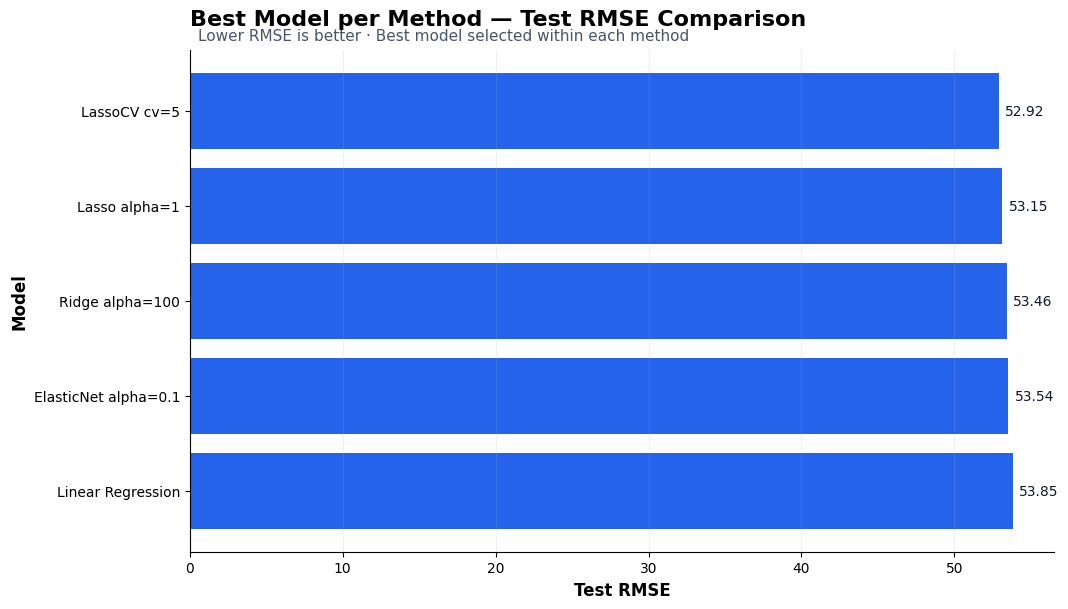

In [21]:
# ============================================================
# CELL 21 — PLOT BEST MODEL PER METHOD
# ============================================================

# Select the best model within each method by lowest test RMSE.
best_per_method = comparison_table.sort_values("Test RMSE").groupby("Method", as_index=False).first()

# Sort selected models by RMSE for clean chart order.
best_per_method = best_per_method.sort_values("Test RMSE", ascending=True)

# Create the chart.
fig, ax = plt.subplots(figsize=(10.8, 6.2))

# Plot horizontal bars.
bars = ax.barh(best_per_method["Model"], best_per_method["Test RMSE"], color="#2563eb")

# Put the best model at the top.
ax.invert_yaxis()

# Add value labels at the end of each bar.
for bar in bars:
    width = bar.get_width()
    ax.text(width + 0.4, bar.get_y() + bar.get_height() / 2, f"{width:.2f}", va="center", fontsize=10, color="#0f172a")

# Add chart title and subtitle.
ax.set_title("Best Model per Method — Test RMSE Comparison", fontsize=16, fontweight="bold", loc="left", pad=18)
ax.text(0.01, 1.02, "Lower RMSE is better · Best model selected within each method", transform=ax.transAxes, fontsize=11, color="#475569")

# Label axes clearly.
ax.set_xlabel("Test RMSE", fontsize=12, fontweight="bold")
ax.set_ylabel("Model", fontsize=12, fontweight="bold")

# Improve chart appearance.
ax.grid(axis="x", alpha=0.20)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

# Make layout print-friendly.
plt.tight_layout()
plt.show()

# Explain the chart.
show_conclusion(
    "Final comparison chart complete",
    f"The chart summarizes the best model from each method family. The lowest-RMSE option is <b>{best_per_method.iloc[0]['Model']}</b> with test RMSE <b>{best_per_method.iloc[0]['Test RMSE']:.3f}</b>."
)

<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">24. Multicollinearity Check with VIF</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p><b>Multicollinearity</b> means features overlap strongly with each other. This can make normal Linear Regression coefficients unstable.</p>
    <p><b>VIF</b> stands for Variance Inflation Factor. Higher VIF suggests a feature can be predicted well from other features, meaning it may be redundant.</p>
    <p><b>Why it belongs here:</b> Ridge and ElasticNet are useful when features overlap. Lasso may remove some redundant features entirely.</p>
  </div>
</div>

In [22]:
# ============================================================
# CELL 22 — CALCULATE VIF MANUALLY
# ============================================================

# Store VIF results for each feature.
vif_rows = []

# Calculate one VIF value per feature.
for feature_name in feature_columns:
    # y_vif is the current feature we try to predict from other features.
    y_vif = X_train_scaled[feature_name]

    # X_vif contains all other features except the current one.
    X_vif = X_train_scaled.drop(columns=[feature_name])

    # Fit a linear model to predict the current feature from the other features.
    vif_model = SklearnLinearRegression()
    vif_model.fit(X_vif, y_vif)

    # R² tells how well the other features explain this feature.
    r_squared = vif_model.score(X_vif, y_vif)

    # VIF formula is 1 / (1 - R²). Add safety when R² is extremely close to 1.
    vif_value = np.inf if np.isclose(1 - r_squared, 0) else 1 / (1 - r_squared)

    # Store the result.
    vif_rows.append({
        "Feature": feature_name,
        "R² from other features": r_squared,
        "VIF": vif_value,
    })

# Create and sort the VIF table.
vif_table = pd.DataFrame(vif_rows).sort_values("VIF", ascending=False)

# Display the VIF table.
display(vif_table.round(4))

# Count potentially high VIF features using a practical threshold.
high_vif_count = int((vif_table["VIF"] > 5).sum())

# Explain the VIF output.
show_conclusion(
    "VIF multicollinearity check complete",
    f"The highest VIF is <b>{vif_table['VIF'].max():.3f}</b>. There are <b>{high_vif_count}</b> features with VIF above 5. Regularization is especially useful when VIF values are high because it stabilizes coefficient behavior."
)

,Feature,R² from other features,VIF
4,s1,0.9819,55.2521
5,s2,0.9720,35.7593
6,s3,0.9300,14.2856
8,s5,0.9007,10.0712
7,s4,0.8929,9.3330
2,bmi,0.3645,1.5736
9,s6,0.3336,1.5007
3,bp,0.2968,1.4221
1,sex,0.2119,1.2689
0,age,0.1784,1.2171


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">25. Final Business Recommendation</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This section converts the technical model comparison into a business recommendation.</p>
    <p><b>Decision logic:</b> choose the model with strong test performance, reasonable simplicity, and clear interpretability. In real work, the best RMSE model is not always the best business model if it is unstable or too hard to explain.</p>
  </div>
</div>

In [23]:
# ============================================================
# CELL 23 — CREATE BUSINESS RECOMMENDATION TABLE
# ============================================================

# Identify the best model overall by test RMSE.
best_overall_model = comparison_table_sorted.iloc[0]

# Create a recommendation table that explains when to use each method.
recommendation_table = pd.DataFrame([
    {
        "Model Family": "Linear Regression",
        "Best Use Case": "Simple baseline and easy coefficient explanation",
        "Main Strength": "High interpretability",
        "Main Risk": "Can be unstable with correlated features",
    },
    {
        "Model Family": "Ridge",
        "Best Use Case": "Many related features with shared signal",
        "Main Strength": "Stable shrinkage while keeping all features",
        "Main Risk": "Does not perform feature selection",
    },
    {
        "Model Family": "Lasso",
        "Best Use Case": "Feature selection and simpler models",
        "Main Strength": "Can remove weak features automatically",
        "Main Risk": "Can be too aggressive with correlated features",
    },
    {
        "Model Family": "ElasticNet",
        "Best Use Case": "Correlated features plus feature selection need",
        "Main Strength": "Balanced Ridge + Lasso behavior",
        "Main Risk": "Needs tuning of alpha and l1_ratio",
    },
    {
        "Model Family": "LassoCV",
        "Best Use Case": "Automatic alpha selection through cross-validation",
        "Main Strength": "More stable alpha choice than manual guessing",
        "Main Risk": "Still only as good as the validation setup",
    },
])

# Display the recommendation table.
display(recommendation_table)

# Show the final recommendation from actual model results.
show_conclusion(
    "Business recommendation",
    f"Based on this run, the best test-RMSE model is <b>{best_overall_model['Model']}</b> with test RMSE <b>{best_overall_model['Test RMSE']:.3f}</b>. For business reporting, pair this result with coefficient stability and the VIF check before making a final production decision."
)

,Model Family,Best Use Case,Main Strength,Main Risk
0,Linear Regression,Simple baseline and easy coefficient explanation,High interpretability,Can be unstable with correlated features
1,Ridge,Many related features with shared signal,Stable shrinkage while keeping all features,Does not perform feature selection
2,Lasso,Feature selection and simpler models,Can remove weak features automatically,Can be too aggressive with correlated features
3,ElasticNet,Correlated features plus feature selection need,Balanced Ridge + Lasso behavior,Needs tuning of alpha and l1_ratio
4,LassoCV,Automatic alpha selection through cross-valida...,More stable alpha choice than manual guessing,Still only as good as the validation setup


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">26. Final MVD Coverage Checklist</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p>This final checklist proves that the Intermediate MVD tasks were implemented, not only mentioned.</p>
  </div>
</div>

In [24]:
# ============================================================
# CELL 24 — FINAL COVERAGE CHECKLIST
# ============================================================

# Create a checklist of required and additional topics covered in this notebook.
coverage_checklist = pd.DataFrame([
    {"Area": "MVD", "Requirement": "Train Ridge, Lasso and ElasticNet", "Evidence": "Cells 10–12", "Status": "Covered"},
    {"Area": "MVD", "Requirement": "Use alpha values 0.1, 1, 10, 100", "Evidence": "alpha_values list and model loops", "Status": "Covered"},
    {"Area": "MVD", "Requirement": "Plot RMSE against alpha", "Evidence": "RMSE-vs-alpha chart", "Status": "Covered"},
    {"Area": "MVD", "Requirement": "Visualize Lasso coefficient path", "Evidence": "Lasso path calculation and chart", "Status": "Covered"},
    {"Area": "MVD", "Requirement": "Identify features set to zero first", "Evidence": "zero_entry_table", "Status": "Covered"},
    {"Area": "MVD", "Requirement": "Run LassoCV with cv=5", "Evidence": "LassoCV section", "Status": "Covered"},
    {"Area": "MVD", "Requirement": "Compare LassoCV RMSE with unregularized model", "Evidence": "final model comparison table", "Status": "Covered"},
    {"Area": "Additional", "Requirement": "Explain scaling and avoid data leakage", "Evidence": "scaling section", "Status": "Covered"},
    {"Area": "Additional", "Requirement": "Compare coefficient shrinkage", "Evidence": "coefficient table and chart", "Status": "Covered"},
    {"Area": "Additional", "Requirement": "Check multicollinearity using VIF", "Evidence": "manual VIF section", "Status": "Covered"},
    {"Area": "Additional", "Requirement": "Provide business recommendation", "Evidence": "recommendation table", "Status": "Covered"},
])

# Display the final checklist.
display(coverage_checklist)

# Count covered items.
covered_count = int((coverage_checklist["Status"] == "Covered").sum())
total_count = len(coverage_checklist)

# Final checklist conclusion.
show_conclusion(
    "Notebook 2 coverage complete",
    f"This notebook covers <b>{covered_count}/{total_count}</b> listed MVD and additional requirements. The core Intermediate MVD requirements are fully implemented with code, charts, output-aware conclusions and a final business recommendation."
)

,Area,Requirement,Evidence,Status
0,MVD,"Train Ridge, Lasso and ElasticNet",Cells 10–12,Covered
1,MVD,"Use alpha values 0.1, 1, 10, 100",alpha_values list and model loops,Covered
2,MVD,Plot RMSE against alpha,RMSE-vs-alpha chart,Covered
3,MVD,Visualize Lasso coefficient path,Lasso path calculation and chart,Covered
4,MVD,Identify features set to zero first,zero_entry_table,Covered
5,MVD,Run LassoCV with cv=5,LassoCV section,Covered
6,MVD,Compare LassoCV RMSE with unregularized model,final model comparison table,Covered
7,Additional,Explain scaling and avoid data leakage,scaling section,Covered
8,Additional,Compare coefficient shrinkage,coefficient table and chart,Covered
9,Additional,Check multicollinearity using VIF,manual VIF section,Covered


<div style="font-family:Arial, sans-serif; background:#ffffff; color:#1f2937;">
  <div style="background:#111827; color:white; padding:18px 22px; border-radius:10px; margin:18px 0 12px 0; border-left:6px solid #3b82f6;">
    <h2 style="margin:0; font-size:22px;">27. Theory Summary — Ridge, Lasso and ElasticNet</h2>
  </div>
  <div style="border:1px solid #dbeafe; background:#eff6ff; padding:16px 18px; border-radius:10px; line-height:1.62; font-size:15px;">
    <p><b>Linear Regression</b> estimates coefficients that minimize prediction error. It is easy to explain, but when features are correlated or when there are many features, coefficients can become unstable.</p>
    <p><b>Ridge Regression</b> adds an L2 penalty. It shrinks coefficients toward zero, but usually does not make them exactly zero. Ridge is useful when many features are related and each may contain some signal.</p>
    <p><b>Lasso Regression</b> adds an L1 penalty. It can set coefficients to exactly zero. This makes Lasso useful for feature selection because it can remove weak or redundant features.</p>
    <p><b>ElasticNet</b> combines L1 and L2 penalties. It is helpful when we want feature selection but also need more stability with correlated features.</p>
    <p><b>Alpha</b> controls regularization strength. A very small alpha behaves closer to normal Linear Regression. A very large alpha can over-shrink the model and cause underfitting.</p>
    <p><b>LassoCV</b> uses cross-validation to choose alpha more systematically. Instead of guessing a penalty strength manually, it tests many options using validation folds.</p>
    <p><b>Final learning:</b> regularization is not only about improving RMSE. It is also about making coefficients more stable, reducing overfitting risk and creating models that are easier to explain in business settings.</p>
  </div>
</div>